In [24]:
#!/bin/bash
!curl -L -o telco-customer-churn.zip\
  https://www.kaggle.com/api/v1/datasets/download/blastchar/telco-customer-churn

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  171k  100  171k    0     0   544k      0 --:--:-- --:--:-- --:--:--  544k


In [25]:
!unzip /content/telco-customer-churn.zip

Archive:  /content/telco-customer-churn.zip
replace WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [28]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ", np.nan))

In [31]:
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [32]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [33]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [34]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [35]:
df.drop(columns=['customerID'], inplace=True)

In [36]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


/tmp/ipykernel_6579/1314700520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


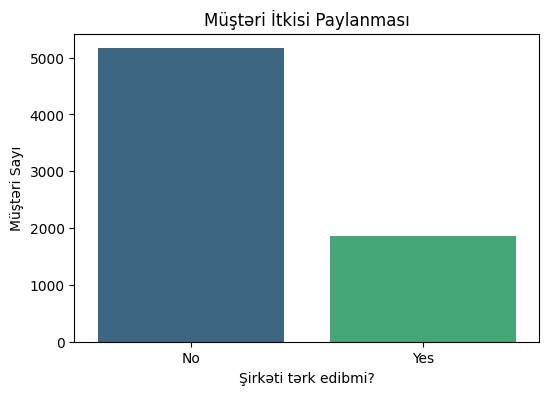

In [37]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Müştəri İtkisi Paylanması')
plt.xlabel('Şirkəti tərk edibmi?')
plt.ylabel('Müştəri Sayı')

plt.show()

/tmp/ipykernel_6579/4050386556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='pastel')
/tmp/ipykernel_6579/4050386556.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='pastel')
/tmp/ipykernel_6579/4050386556.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2], palette='pastel')


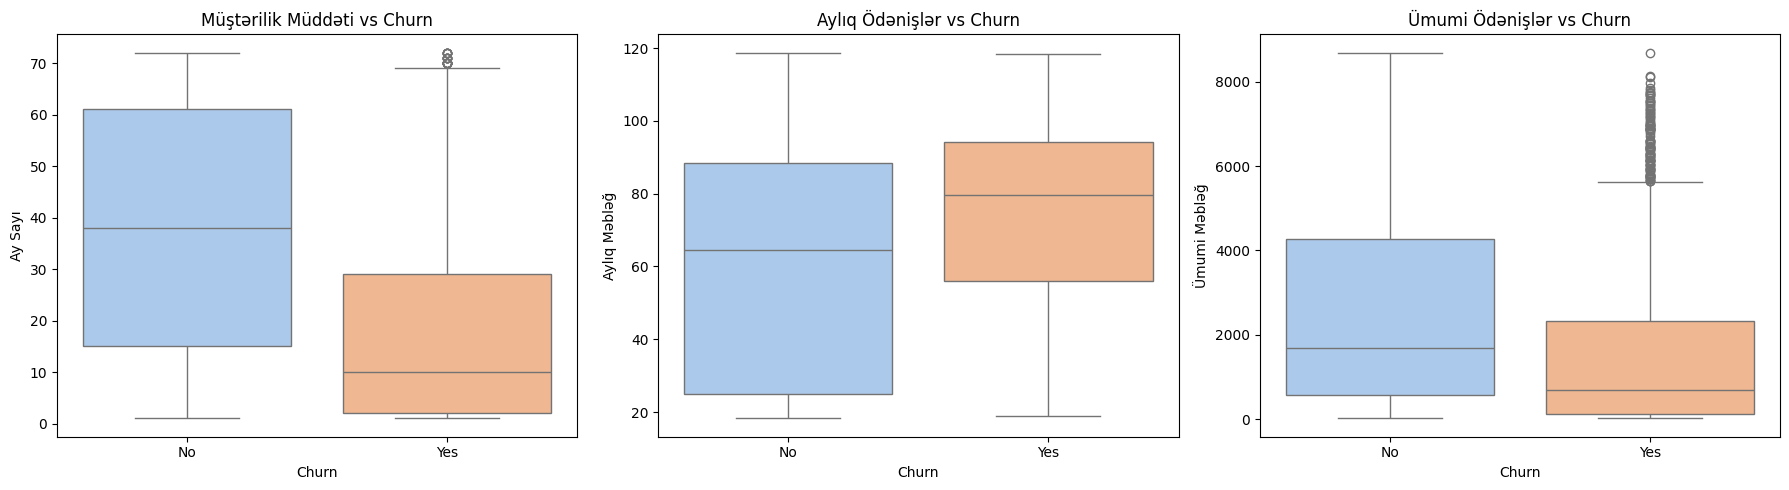

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='pastel')
axes[0].set_title('Müştərilik Müddəti vs Churn')
axes[0].set_ylabel('Ay Sayı')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='pastel')
axes[1].set_title('Aylıq Ödənişlər vs Churn')
axes[1].set_ylabel('Aylıq Məbləğ')

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2], palette='pastel')
axes[2].set_title('Ümumi Ödənişlər vs Churn')
axes[2].set_ylabel('Ümumi Məbləğ')

plt.tight_layout()
plt.show()

In [39]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [44]:
cat_cols = df.select_dtypes(include=['object']).columns

binary_cols = []
multi_cols = []

for col in cat_cols:
  if df[col].nunique() == 2:
    binary_cols.append(col)
  else:
    multi_cols.append(col)

print(binary_cols)
print(multi_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [45]:
for col in binary_cols:
  unique_values = df[col].unique()
  df[col] = df[col].map({unique_values[0]: 0, unique_values[1]: 1})

In [46]:
df = pd.get_dummies(df, columns=multi_cols, drop_first=True, dtype=int)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

In [50]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,1,0,0,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,1,0,34,1,1,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,1,0,2,1,0,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,1,0,45,0,1,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,1,0,2,1,0,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
scaler = StandardScaler()

In [59]:
X_train_scaler = scaler.fit_transform(X_train)

X_test_scaler = scaler.transform(X_test)

In [60]:
from sklearn.neighbors import KNeighborsClassifier

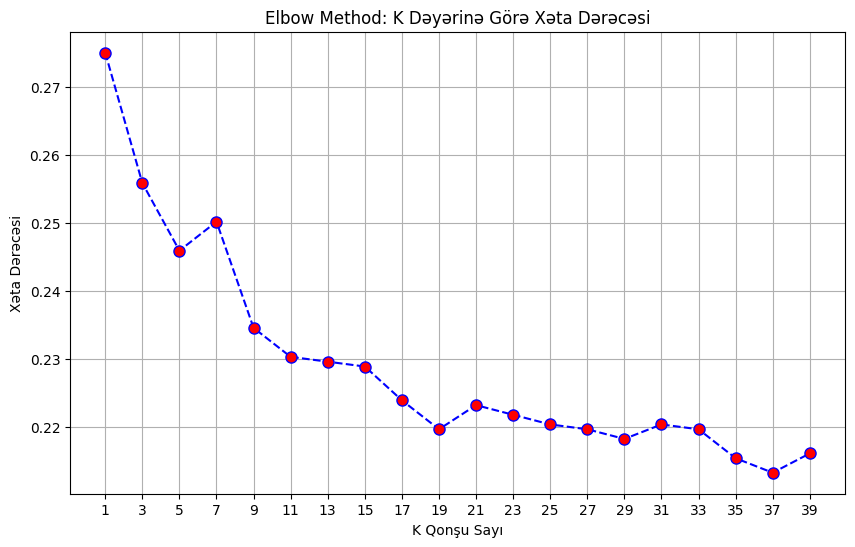

In [67]:
default_knn = KNeighborsClassifier(n_neighbors=5)
default_knn.fit(X_train_scaler, y_train)

error_rate = []

k_range = range(1, 40, 2)

for i in k_range:
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train_scaler, y_train)
  pred_i = knn.predict(X_test_scaler)
  error_rate.append(np.mean(pred_i != y_test))


plt.figure(figsize=(10, 6))
plt.plot(k_range, error_rate, color='blue', marker='o', linestyle='dashed',
                              markerfacecolor='red', markersize=8)
plt.title('Elbow Method: K Dəyərinə Görə Xəta Dərəcəsi')
plt.xlabel('K Qonşu Sayı')
plt.ylabel('Xəta Dərəcəsi')
plt.xticks(list(k_range))
plt.grid(True)

plt.show()

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

In [66]:
best_k = 19

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaler, y_train)
y_pred = final_knn.predict(X_test_scaler)

In [68]:
confusion_matrix(y_test, y_pred)

array([[886, 147],
       [162, 212]])

In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1033
           1       0.59      0.57      0.58       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407

